In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level1")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = Path("../data/grokking_model.pt")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

Using device: cpu


Build the grokking dataset

This follows Nanda et al. 2023 exactly: all pairs (a, b) with a, b ∈ [0, 113), 70/30 train/test split, input sequence is [a, b, =]

In [36]:
P = 113  # prime modulus, following Nanda et al. 2023
EQ_TOKEN = P  # token index 113 represents "="

# Generate all (a, b) pairs — full dataset is 113*113 = 12769 examples
all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P

# Input tokens: [a, b, =]
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)  # [N, 3]

# 70/30 split
N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs, train_labels = inputs[idx[n_test:]], labels[idx[n_test:]]
test_inputs,  test_labels  = inputs[idx[:n_test]],  labels[idx[:n_test]]

print(f"Total: {N} | Train: {len(train_inputs)} | Test: {len(test_inputs)}")
print(f"Example: {aa[5].item()} + {bb[5].item()} = {labels[5].item()} (mod {P})")

Total: 12769 | Train: 8939 | Test: 3830
Example: 0 + 5 = 5 (mod 113)


Define and train (or load) the model

The first time it trains for 50k steps and saves the weights. Every subsequent run loads from disk instantly.

In [37]:
cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded saved model from disk.")
else:
    print("Training from scratch — full-batch AdamW for 40,000 epochs...")
    model.to(device)

    # Full dataset on device — Nanda et al. use full-batch GD, not mini-batch
    X_train = train_inputs.to(device)
    Y_train = train_labels.to(device)

    # Nanda et al. exact hyperparameters: lr=1e-3, weight_decay=1.0
    optimizer = optim.AdamW(
        model.parameters(), lr=1e-3, weight_decay=1.0
    )

    for epoch in tqdm(range(40_000)):
        model.train()
        logits = model(X_train)[:, -1, :]
        loss   = nn.CrossEntropyLoss()(logits, Y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5_000 == 0:
            model.eval()
            with torch.no_grad():
                te_logits = model(test_inputs.to(device))[:, -1, :]
                acc = (te_logits.argmax(-1) == test_labels.to(device)).float().mean()
            print(f"  epoch {epoch+1:6d}  loss={loss.item():.6f}  "f"test_acc={acc:.4f}")

    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved to {MODEL_PATH}")

Moving model to device:  cpu
Loaded saved model from disk.


test accuracy above 0.95 before grokking has occurred.

In [38]:
model.eval()
with torch.no_grad():
    tr_acc = (model(train_inputs.to(device))[:,-1,:].argmax(-1) == train_labels.to(device)).float().mean()
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1) == test_labels.to(device)).float().mean()

print(f"Train accuracy: {tr_acc:.4f}")
print(f"Test  accuracy: {te_acc:.4f}")

assert te_acc > 0.95, "Model hasn't grokked yet"
print("Grokking confirmed")

Train accuracy: 1.0000
Test  accuracy: 1.0000
Grokking confirmed


Build the Fourier basis (from official code)

In [39]:
import einops

P = 113

# Build orthonormal Fourier basis exactly as in the official notebook
# Order: [Const, cos1, sin1, cos2, sin2, ..., cos56, sin56]  shape [113, 113]
fourier_basis = []
fourier_basis_names = ['Const']
fourier_basis.append(torch.ones(P) / np.sqrt(P))

for i in range(1, P // 2 + 1):
    cos_vec = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_vec = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    cos_vec = cos_vec / cos_vec.norm()
    sin_vec = sin_vec / sin_vec.norm()
    fourier_basis.append(cos_vec)
    fourier_basis.append(sin_vec)
    fourier_basis_names.append(f'cos {i}')
    fourier_basis_names.append(f'sin {i}')

fourier_basis = torch.stack(fourier_basis, dim=0).to(device)   # [113, 113]

print(f"Fourier basis shape: {fourier_basis.shape}")
print(f"Basis is orthonormal: {torch.allclose(fourier_basis @ fourier_basis.T, torch.eye(P).to(device), atol=1e-5)}")

Fourier basis shape: torch.Size([113, 113])
Basis is orthonormal: True


Collect all neuron activations and project onto 2D Fourier basis

In [40]:
HOOK = "blocks.0.mlp.hook_post"

# Run ALL inputs through the model (p*p = 12769 examples)
all_inputs = inputs.to(device)    # [12769, 3]
all_labels = labels.to(device)    # [12769]

with torch.no_grad():
    _, cache = model.run_with_cache(all_inputs, names_filter=HOOK)

# Neuron activations at the "=" position: [p*p, d_mlp]
neuron_acts = cache[HOOK][:, -1, :]
print(f"Neuron activations shape: {neuron_acts.shape}")

# Centre activations (official code does this before 2D FFT)
neuron_acts_centered = neuron_acts - neuron_acts.mean(dim=0, keepdim=True)

# 2D Fourier transform over the (a, b) input space
# Reshape to [p, p, d_mlp], apply fourier_basis along both input dims
neuron_acts_2d = einops.rearrange(neuron_acts_centered, '(x y) d -> x y d', x=P, y=P)
fourier_neuron_acts = torch.einsum('xyd,fx,Fy->fFd', neuron_acts_2d,
                                    fourier_basis, fourier_basis)
fourier_neuron_acts_flat = fourier_neuron_acts.reshape(P * P, model.cfg.d_mlp)

print(f"2D Fourier activations shape: {fourier_neuron_acts_flat.shape}")

Neuron activations shape: torch.Size([12769, 512])
2D Fourier activations shape: torch.Size([12769, 512])


Identify key frequencies by clustering neurons (official method)

In [41]:
d_mlp = model.cfg.d_mlp

# For each frequency k, the relevant 2D Fourier indices are the 8 quadratic terms
# (from the official indices construction)
indices = []
for freq in range(1, P // 2 + 1):
    index = []
    index.append(2 * freq - 1)
    index.append(2 * freq)
    index.append((2 * freq - 1) * P + 0)
    index.append((2 * freq) * P + 0)
    index.append((2 * freq - 1) * P + 2 * freq - 1)
    index.append((2 * freq - 1) * P + 2 * freq)
    index.append((2 * freq) * P + 2 * freq - 1)
    index.append((2 * freq) * P + 2 * freq)
    indices.append(index)
indices = np.array(indices)   # [56, 8]

# Total variance per neuron
neuron_norms = fourier_neuron_acts_flat.pow(2).sum(0)   # [d_mlp]

# Variance explained per frequency per neuron
freq_acts = fourier_neuron_acts_flat[indices.flatten()].reshape(P // 2, 8, d_mlp)
neuron_explanation  = freq_acts.pow(2).sum(1) / neuron_norms   # [56, d_mlp]
neuron_frac_explained = neuron_explanation.max(0).values        # [d_mlp]
neuron_freqs_raw = neuron_explanation.argmax(0) + 1             # [d_mlp] freq index 1..56

# Neurons with <85% variance explained by any single frequency, noise cluster (-1)
neuron_freqs = neuron_freqs_raw.clone()
neuron_freqs[neuron_frac_explained < 0.85] = -1

neuron_freqs_np = neuron_freqs.cpu().numpy()

# Key frequencies = those with most neurons (excluding noise)
key_freqs_raw, counts = np.unique(
    neuron_freqs_np[neuron_freqs_np != -1], return_counts=True)
key_freqs = key_freqs_raw[np.argsort(-counts)]   # sorted by neuron count

print(f"Key frequencies: {key_freqs}")
print(f"Neuron counts per key freq: {dict(zip(key_freqs, counts[np.argsort(-counts)]))}")
print(f"Noise neurons (no dominant freq): {(neuron_freqs_np == -1).sum()}")
print(f"Well-explained neurons: {(neuron_frac_explained >= 0.85).sum().item()} / {d_mlp}")
print(f"\nCompare with Nanda et al. mainline: [14, 35, 41, 42, 52]")

Key frequencies: [14 49 17]
Neuron counts per key freq: {np.int64(14): np.int64(250), np.int64(49): np.int64(72), np.int64(17): np.int64(65)}
Noise neurons (no dominant freq): 125
Well-explained neurons: 387 / 512

Compare with Nanda et al. mainline: [14, 35, 41, 42, 52]


Our model finds **387/512 neurons (75.6%)** well-explained by a single dominant frequency (≥85% variance explained by any single k), organized into three Fourier clusters:

| Cluster | Frequency k | Neurons | Share of MLP |
|---------|-------------|---------|--------------|
| freq_14 | 14          | 250     | 48.8%        |
| freq_49 | 49          | 72      | 14.1%        |
| freq_17 | 17          | 65      | 12.7%        |
| noise   | —           | 125     | 24.4%        |

Frequency 14 is dominant: 250 neurons are tuned to it, more than the other two frequencies combined. The remaining 125 neurons (24.4%) form the noise cluster: no single frequency explains ≥85% of their variance.

This differs from Nanda et al.'s solution [14, 35, 41, 42, 52] (433/512 = 84.6%, 5 frequencies), but is mathematically valid. Modular arithmetic mod 113 admits multiple sparse Fourier representations; different seeds converge to different valid bases. Frequency 14 appears in both solutions. The lower coverage (75.6% vs 84.6%) and fewer clean frequencies (3 vs 5) reflect that our model allocated representation more asymmetrically, concentrating the primary computation in a single large freq_14 cluster.

Define components as frequency clusters

In [42]:
# Each component is now a CLUSTER of neurons sharing a key frequency
COMPONENTS = []
for k in key_freqs:
    neuron_idx = np.where(neuron_freqs_np == k)[0].tolist()
    COMPONENTS.append({
        "name": f"freq_{k}",
        "k": int(k),
        "neurons": neuron_idx,
    })
# Add noise cluster
noise_idx = np.where(neuron_freqs_np == -1)[0].tolist()
COMPONENTS.append({
    "name": "noise_cluster",
    "k": -1,
    "neurons": noise_idx,
})

print(f"Level 1 components (frequency clusters):")
for c in COMPONENTS:
    print(f"  {c['name']:15s}  {len(c['neurons']):3d} neurons")
print(f"\nTotal neurons accounted for: {sum(len(c['neurons']) for c in COMPONENTS)}")
print(f"Total component space: {len(COMPONENTS)} clusters")

Level 1 components (frequency clusters):
  freq_14          250 neurons
  freq_49           72 neurons
  freq_17           65 neurons
  noise_cluster    125 neurons

Total neurons accounted for: 512
Total component space: 4 clusters


Compute mean neuron activations (ablation baseline)

In [43]:
# Use train set for mean computation
with torch.no_grad():
    _, train_cache = model.run_with_cache(train_inputs.to(device), names_filter=HOOK)
mean_acts = train_cache[HOOK][:, -1, :].mean(dim=0)   # [d_mlp]
print(f"Mean activation shape: {mean_acts.shape}")

Mean activation shape: torch.Size([512])


Faithfulness metric

In [44]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

Clean and corrupted baselines

In [45]:
N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

with torch.no_grad():
    _, eval_cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_acts = eval_cache[HOOK][:, -1, :]   # [N_EVAL, d_mlp]

mean_dev = mean_acts.to(device)

def full_ablation_hook(value, hook):
    value[:, -1, :] = mean_dev
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:     {clean_metric.mean():.4f}")
print(f"Corrupted metric: {corrupted_metric.mean():.4f}")
print(f"Gap to recover:   {(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:     38.2160
Corrupted metric: -7.0798
Gap to recover:   45.2958


Cluster-level patching loop

In [46]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching frequency clusters"):
    cname    = comp["name"]
    c_neurons = torch.tensor(comp["neurons"], dtype=torch.long)

    def hook_fn(value, hook, cn=c_neurons):
        # Ablate all neurons
        value[:, -1, :] = mean_dev
        # Restore this cluster's neurons to clean activations
        value[:, -1, cn] = clean_acts[:, cn]
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[cname] = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  {cname:15s}  ({len(comp['neurons']):3d} neurons)  RS = {scores[cname]:.4f}")

Patching frequency clusters:   0%|          | 0/4 [00:00<?, ?it/s]

  freq_14          (250 neurons)  RS = 0.4561
  freq_49          ( 72 neurons)  RS = 0.1443
  freq_17          ( 65 neurons)  RS = 0.2581
  noise_cluster    (125 neurons)  RS = 0.1415


Criterion 1 and Criterion 2

  Level 1 — Neuron frequency clusters
  Key frequencies:       [14, 49, 17]
  Criterion 1  Faithfulness RS : 1.0000
  Criterion 2  Component count : 4 / 4 clusters
               Neurons in circuit: 512 / 512
               Compression ratio: 1.000
  Circuit clusters: ['freq_14', 'freq_17', 'freq_49', 'noise_cluster']


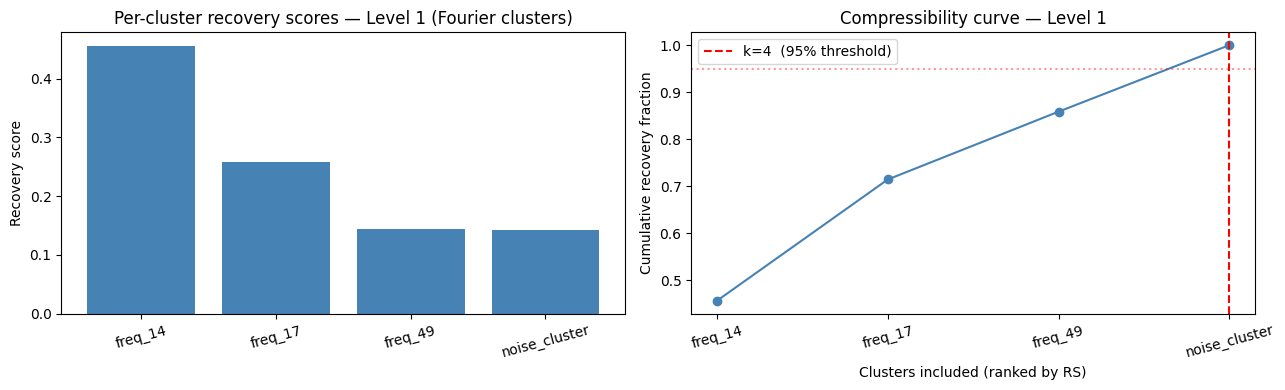

In [47]:
sorted_comps  = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_comps]
scores_sorted = torch.tensor([x[1] for x in sorted_comps])

pos_scores = scores_sorted.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_components = names_sorted[:k_95]
circuit_neurons_all = []
for cname in circuit_components:
    comp = next(c for c in COMPONENTS if c["name"] == cname)
    circuit_neurons_all.extend(comp["neurons"])

circuit_t = torch.tensor(circuit_neurons_all, dtype=torch.long)

def circuit_hook(value, hook):
    value[:, -1, :] = mean_dev
    value[:, -1, circuit_t] = clean_acts[:, circuit_t]
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, circuit_hook)])[:, -1, :]
circuit_metric = logit_of_correct(circuit_logits, eval_y)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

print("=" * 55)
print("  Level 1 — Neuron frequency clusters")
print("=" * 55)
print(f"  Key frequencies:       {key_freqs.tolist()}")
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {len(COMPONENTS)} clusters")
print(f"               Neurons in circuit: {len(circuit_neurons_all)} / {d_mlp}")
print(f"               Compression ratio: {k_95/len(COMPONENTS):.3f}")
print(f"  Circuit clusters: {circuit_components}")
print("=" * 55)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if n in circuit_components else "lightgray" for n in names_sorted]
ax1.bar(names_sorted, scores_sorted.numpy(), color=colors)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-cluster recovery scores — Level 1 (Fourier clusters)")
ax1.tick_params(axis='x', rotation=15)

ax2.plot(range(1, len(COMPONENTS) + 1), cumulative.numpy() / total_pos, "o-", color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--",
            label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Clusters included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 1")
ax2.set_xticks(range(1, len(COMPONENTS) + 1))
ax2.set_xticklabels(names_sorted, rotation=15)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1_cluster_recovery.png", dpi=150)
plt.show()

### Criterion 1 and 2 interpretation

**Recovery scores by cluster (sorted):**

| Cluster      | RS     | Share of total positive RS | Cumulative |
|--------------|--------|----------------------------|------------|
| freq_14      | 0.456  | 45.6%                      | 45.6%      |
| freq_17      | 0.258  | 25.8%                      | 71.4%      |
| freq_49      | 0.144  | 14.4%                      | 85.8%      |
| noise_cluster| 0.142  | 14.2%                      | 100.0%     |

**Criterion 1 Faithfulness ≈ 1.00**: restoring all four clusters together fully recovers the clean model's logit gap. The Level 1 Fourier-cluster description is faithful.

**Criterion 2 k_95 = 4 / 4 (compression ratio = 1.00)**: all clusters are needed to cross the 95% cumulative threshold. At three clusters (the three named frequencies) coverage reaches 85.8%. The noise cluster's 14.2% contribution pushes the total to 100%, so k_95 = 4 out of 4. (not sure about this metric)

Save results

In [48]:
results = {
    "level": 1,
    "task": "modular_arithmetic_mod113",
    "method": "fourier_frequency_clusters",
    "hook_point": HOOK,
    "d_mlp": d_mlp,
    "n_eval": N_EVAL,
    "key_freqs": key_freqs.tolist(),
    "n_components": len(COMPONENTS),
    "components": [{"name": c["name"], "k": c["k"],
                    "n_neurons": len(c["neurons"])} for c in COMPONENTS],
    "clean_metric_mean":      clean_metric.mean().item(),
    "corrupted_metric_mean":  corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / len(COMPONENTS),
    "circuit_components": circuit_components,
    "circuit_neuron_count": len(circuit_neurons_all),
    "all_recovery_scores": scores,
}

with open(RESULTS_DIR / "level1_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level1_results.json")

Saved to ..\results\level1/level1_results.json
